# Pipeline 4 - Metrics

In [69]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from swot_toolkit.pipe4 import calc_opera_metrics, calc_swot_metrics


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## METRICS - ONE SITE

The reference mask is expected to have 3 values: 
* 0 - not water
* 1 - water
* 2 - no data

In [78]:
# REGION = "Northeast"
# DATE = "2025-07-20"

# REGION = "Rio_Branco"
# DATE = "2025-09-07"

REGION = "Curua-Una"
DATE = "2025-08-14"

# REGION = "Rio_Madeira"
# DATE = "2025-07-21"

# REGION = "Rio_Negro"
# DATE = "2025-08-07"


METRICS = ["iou", "f1", "precision", "recall"]

### Assess Opera (S1 and S2) masks

The opera mask has values 1 and 2 representing water and parcial water. So they will be set to 1. Other values above 200 are no data that will be set to 3 (flagged)

In [71]:
opera_results = calc_opera_metrics(REGION, DATE, METRICS)

In [72]:
opera_results

,opera_s2,opera_s2 incl. partial,opera_s1,opera_s1 incl. partial
iou,0.7739,0.7832,0.6903,0.7310
f1,0.8725,0.8784,0.8168,0.8446
precision,0.9982,0.8525,0.9941,0.9285
recall,0.7750,0.9059,0.6931,0.7747


### Assess SWOT

In [75]:
swot_results = calc_swot_metrics(REGION, DATE, METRICS)

Processing scenario: as is
Processing scenario: exclude no data


Processing scenario: exclude bad
Processing scenario: exclude (bad, degraded)
Processing scenario: exclude (bad, degraded, suspect)


In [77]:
output_dir, _, _ = open_output_dir(REGION, DATE)
all_results = pd.concat([opera_results, swot_results], axis=1)
# all_results.to_parquet(output_dir / "results.parquet")
all_results

,opera_s2,opera_s2 incl. partial,opera_s1,opera_s1 incl. partial,as is,exclude no data,exclude bad,"exclude (bad, degraded)","exclude (bad, degraded, suspect)"
iou,0.7739,0.7832,0.6903,0.7310,0.5682,0.5423,0.5704,0.5704,0.2772
f1,0.8725,0.8784,0.8168,0.8446,0.7247,0.7032,0.7265,0.7265,0.4341
precision,0.9982,0.8525,0.9941,0.9285,0.7807,0.7768,0.7678,0.7678,0.9678
recall,0.7750,0.9059,0.6931,0.7747,0.6762,0.6424,0.6893,0.6893,0.2798


## Process All Sites

In [ ]:
from swot_toolkit.analysis import open_sites_and_dates

sites_dates = open_sites_and_dates("/data/swot/output")

METRICS = ["iou", "f1", "precision", "recall"]

all_results = pd.DataFrame()
for site, dates in sites_dates.items():
    for date in dates:
        site_results = pd.DataFrame()
        print(f"Processing {site} - {date}")
        opera_results = calc_opera_metrics(site, date, METRICS)
        swot_results = calc_swot_metrics(site, date, METRICS)

        output_dir, _, _ = open_output_dir(site, date)
        site_results = pd.concat([opera_results, swot_results], axis=1)
        site_results.to_parquet(output_dir / "results.parquet")

        site_results.index = pd.MultiIndex.from_product(
            [[f"{site} {date}"], site_results.index],
            names=["site", "metric"],
        )
        all_results = pd.concat([all_results, site_results], axis=0)

Processing Curua-Una - 2025-08-14
Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Processing scenario: as is
Processing scenario: exclude no data
Processing scenario: exclude bad
Processing scenario: exclude (bad, degraded)
Processing scenario: exclude (bad, degraded, suspect)
Processing Northeast - 2025-07-20
Reading KML file: /data/swot/output/Northeast/kml/Northeast.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Processing scenario: as is
Processing scenario: exclude no data
Processing scenario: exclude bad
Processing scenario: exclude (bad, degraded)
Processing scenario: exclude (bad, degraded, suspect)
Processing Rio_Branco - 2025-09-07
Reading KML file: /data/swot/output/Rio_Branco/kml/Rio_Branco.kml
The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']
Processing scenario: as is

In [ ]:
all_results

opera_s2  opera_s2 incl. partial  opera_s1  \
site                   metric                                                  
Curua-Una 2025-08-14   iou          0.8985                  0.8374    0.8607   
                       f1           0.9465                  0.9115    0.9252   
                       precision    0.9963                  0.8673    0.9974   
                       recall       0.9015                  0.9605    0.8627   
Northeast 2025-07-20   iou          0.8573                  0.7756    0.6738   
                       f1           0.9232                  0.8736    0.8051   
                       precision    0.9518                  0.8182    0.9896   
                       recall       0.8962                  0.9371    0.6786   
Rio_Branco 2025-09-07  iou          0.7739                  0.7832    0.6903   
                       f1           0.8725                  0.8784    0.8168   
                       precision    0.9982                  0.8525    0.9941   
                       recall       0.7750                  0.9059    0.6931   
Rio_Madeira 2025-07-21 iou          0.9297                  0.8590    0.9020   
                       f1           0.9636                  0.9242    0.9485   
                       precision    0.9974                  0.8820    0.9940   
                       recall       0.9320                  0.9706    0.9069   
Rio_Negro 2025-08-07   iou          0.9474                  0.8863    0.8713   
                       f1           0.9730                  0.9397    0.9313   
                       precision    0.9964                  0.8969    0.9998   
                       recall       0.9506                  0.9868    0.8715   

                                  opera_s1 incl. partial   as is  \
site                   metric                                      
Curua-Una 2025-08-14   iou                        0.8496  0.7582   
                       f1                         0.9187  0.8625   
                       precision                  0.9788  0.9217   
                       recall                     0.8655  0.8104   
Northeast 2025-07-20   iou                        0.6674  0.3661   
                       f1                         0.8005  0.5359   
                       precision                  0.9464  0.9015   
                       recall                     0.6936  0.3813   
Rio_Branco 2025-09-07  iou                        0.7310  0.5682   
                       f1                         0.8446  0.7247   
                       precision                  0.9285  0.7807   
                       recall                     0.7747  0.6762   
Rio_Madeira 2025-07-21 iou                        0.8999  0.7352   
                       f1                         0.9473  0.8474   
                       precision                  0.9908  0.8226   
                       recall                     0.9075  0.8738   
Rio_Negro 2025-08-07   iou                        0.8694  0.7779   
                       f1                         0.9301  0.8751   
                       precision                  0.9947  0.8959   
                       recall                     0.8734  0.8551   

                                  exclude no data  exclude bad  \
site                   metric                                    
Curua-Una 2025-08-14   iou                 0.7974       0.8111   
                       f1                  0.8873       0.8957   
                       precision           0.9450       0.9250   
                       recall              0.8362       0.8682   
Northeast 2025-07-20   iou                 0.7679       0.7679   
                       f1                  0.8687       0.8687   
                       precision           0.8715       0.8715   
                       recall              0.8659       0.8659   
Rio_Branco 2025-09-07  iou                 0.5423       0.5704   
                       f1                  0.7032 

In [ ]:
site_medians = all_results.groupby(level=1).median()
site_medians.index = pd.MultiIndex.from_product([["MEDIAN"], site_medians.index])

all_results = pd.concat([all_results, site_medians], axis=0)
all_results


opera_s2  opera_s2 incl. partial  opera_s1  \
                       metric                                                  
Curua-Una 2025-08-14   iou          0.8985                  0.8374    0.8607   
                       f1           0.9465                  0.9115    0.9252   
                       precision    0.9963                  0.8673    0.9974   
                       recall       0.9015                  0.9605    0.8627   
Northeast 2025-07-20   iou          0.8573                  0.7756    0.6738   
                       f1           0.9232                  0.8736    0.8051   
                       precision    0.9518                  0.8182    0.9896   
                       recall       0.8962                  0.9371    0.6786   
Rio_Branco 2025-09-07  iou          0.7739                  0.7832    0.6903   
                       f1           0.8725                  0.8784    0.8168   
                       precision    0.9982                  0.8525    0.9941   
                       recall       0.7750                  0.9059    0.6931   
Rio_Madeira 2025-07-21 iou          0.9297                  0.8590    0.9020   
                       f1           0.9636                  0.9242    0.9485   
                       precision    0.9974                  0.8820    0.9940   
                       recall       0.9320                  0.9706    0.9069   
Rio_Negro 2025-08-07   iou          0.9474                  0.8863    0.8713   
                       f1           0.9730                  0.9397    0.9313   
                       precision    0.9964                  0.8969    0.9998   
                       recall       0.9506                  0.9868    0.8715   
MEDIAN                 f1           0.9465                  0.9115    0.9252   
                       iou          0.8985                  0.8374    0.8607   
                       precision    0.9964                  0.8673    0.9941   
                       recall       0.9015                  0.9605    0.8627   

                                  opera_s1 incl. partial   as is  \
                       metric                                      
Curua-Una 2025-08-14   iou                        0.8496  0.7582   
                       f1                         0.9187  0.8625   
                       precision                  0.9788  0.9217   
                       recall                     0.8655  0.8104   
Northeast 2025-07-20   iou                        0.6674  0.3661   
                       f1                         0.8005  0.5359   
                       precision                  0.9464  0.9015   
                       recall                     0.6936  0.3813   
Rio_Branco 2025-09-07  iou                        0.7310  0.5682   
                       f1                         0.8446  0.7247   
                       precision                  0.9285  0.7807   
                       recall                     0.7747  0.6762   
Rio_Madeira 2025-07-21 iou                        0.8999  0.7352   
                       f1                         0.9473  0.8474   
                       precision                  0.9908  0.8226   
                       recall                     0.9075  0.8738   
Rio_Negro 2025-08-07   iou                        0.8694  0.7779   
                       f1                         0.9301  0.8751   
                       precision                  0.9947  0.8959   
                       recall                     0.8734  0.8551   
MEDIAN                 f1                         0.9187  0.8474   
                       iou                        0.8496  0.7352   
                       precision                  0.9788  0.8959   
                       recall                     0.8655  0.8104   

                                  exclude no data  exclude bad  \
                       metric                                    
Curua-Una 2025-08-14   iou                 0.7974   

## Visualize Everything

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from swot_toolkit.pipe4 import plot_s2_rgb, plot_ref_mask
from swot_toolkit.opera import plot_opera_array
from swot_toolkit.swot import create_raster_mosaic

In [82]:
datasets = open_datasets(REGION, DATE)

The following datasets have been opened: ['s2_img', 'scl', 'ref_mask', 'opera_s2', 'opera_s1']


Text(0.5, 1.0, '')

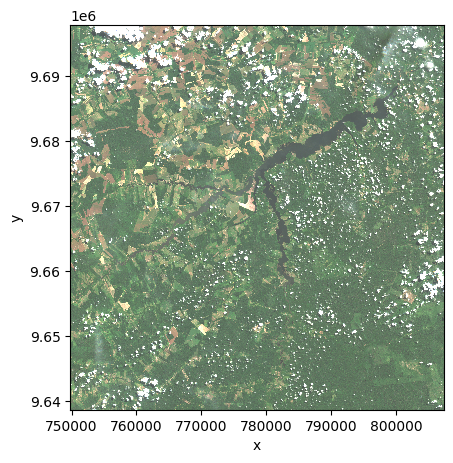

In [87]:
_, ax = plt.subplots(figsize=(5, 5))
plot_s2_rgb(datasets["s2_img"], ax, down_factor=5)
ax.set_title("")

Text(0.5, 1.0, '')

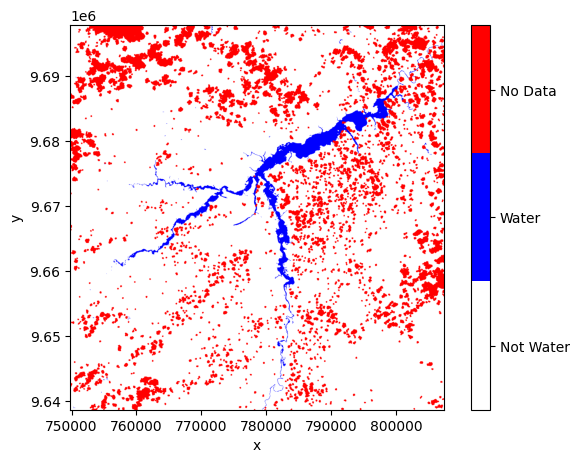

In [91]:
fig, ax = plt.subplots(figsize=(7, 5))

plot_ref_mask(datasets["ref_mask"], ax, down_factor=5)
ax.set_title(None)

Text(0.5, 1.0, '')

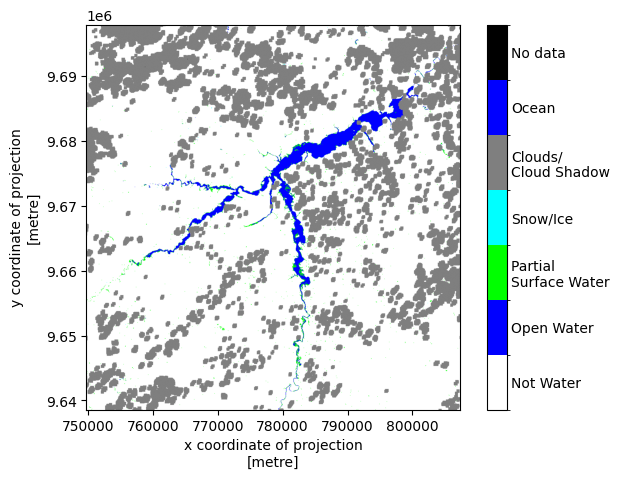

In [99]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_opera_array(datasets["opera_s2"], down_factor=2, ax=ax)
# ax.set_title("OPERA S2-HLS mask")
ax.set_title(None)

Text(0.5, 1.0, '')

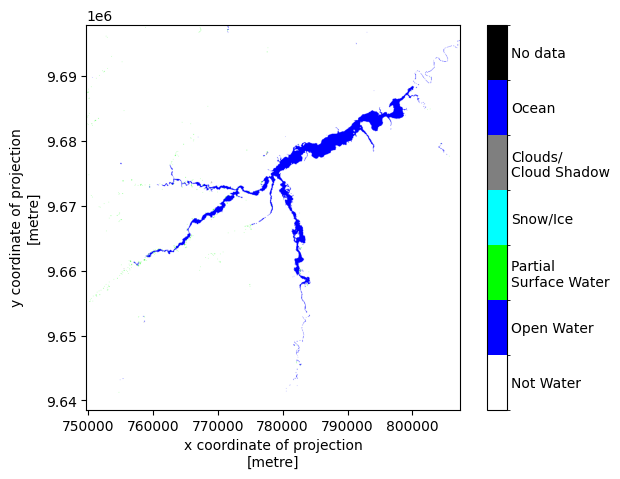

In [100]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_opera_array(datasets["opera_s1"], down_factor=2, ax=ax)
# ax.set_title("OPERA S1 mask")
ax.set_title(None)

In [101]:
swot_mask, patches, no_data_masks = create_swot_mosaic(
    REGION,
    DATE,
    dst_crs=datasets["ref_mask"].rio.crs,
    exclude_flags=None,
    exclude_no_data=True,
)

Text(0.5, 1.0, '')

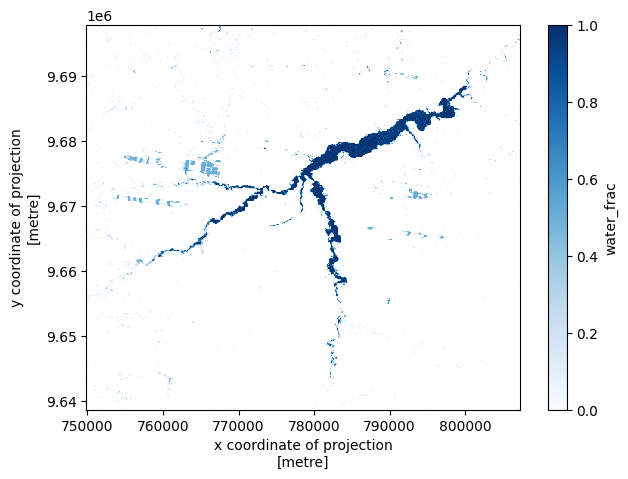

In [103]:
fig, ax = plt.subplots(figsize=(7, 5))
swot_mask = swot_mask.where(swot_mask > 0)
swot_mask["water_frac"].plot(cmap="Blues", vmin=0, vmax=1, ax=ax)
# ax.set_title("SWOT RASTER 100 water fraction")
ax.set_title(None)

In [59]:
swot_mask_proc = process_swot_mask(swot_mask, water_threshold=0.6)


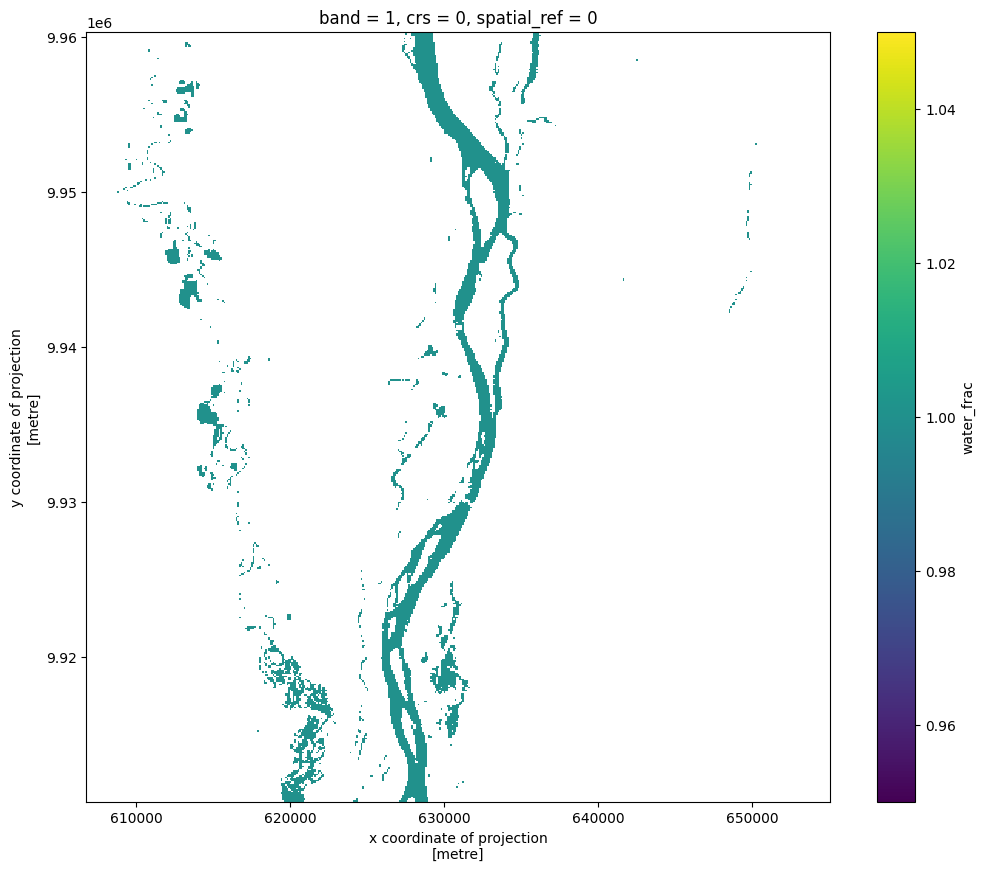

In [63]:
swot_mask_proc.where(swot_mask_proc != 2).where(swot_mask_proc != 0).plot(figsize=(12, 10))

## Testing water threshold (Scenario 3 will be the reference:)


In [ ]:
swot_mask, patches = create_raster_mosaic(
    mosaic_df,
    ref_date=MOSAIC_DATE,
    aoi=aoi,
    variable="water_frac",
    exclude_flags=scenarios["exclude bad"]["exclude_flags"],
    exclude_no_data=True,
)

In [ ]:
ref_mask = ref_mask.rio.reproject_match(swot_mask)

In [ ]:
results = {}

ref_mask_reprojected = ref_mask.rio.reproject_match(swot_mask, resampling=Resampling.mode)
for water_thresh in np.linspace(0.1, 0.9, 9):
    mask = swot_mask["water_frac"].copy()
    mask.data[mask.data >= water_thresh] = 1  # Water
    mask.data[(mask.data > -1) & (mask.data < water_thresh)] = 0  # not water
    mask.data[mask.data < -1] = 0  # not water
    mask.data[mask.data == -1] = 3
    mask = mask.fillna(2).astype("uint8")

    results[f"water > {water_thresh:.1f}"] = calc_metrics(
        ref_mask_reprojected, mask, metrics, binary=True
    )

In [ ]:
pd.DataFrame.from_dict(results, orient="index")

,iou,f1,precision,recall,coverage,water_coverage
water > 0.1,0.5535,0.7126,0.5827,0.9172,1.0,1.0
water > 0.2,0.6298,0.7728,0.6793,0.8962,1.0,1.0
water > 0.3,0.6728,0.8044,0.7417,0.8787,1.0,1.0
water > 0.4,0.6999,0.8235,0.7916,0.8580,1.0,1.0
water > 0.5,0.7156,0.8342,0.8330,0.8355,1.0,1.0
water > 0.6,0.7258,0.8411,0.8749,0.8098,1.0,1.0
water > 0.7,0.7102,0.8305,0.8927,0.7765,1.0,1.0
water > 0.8,0.6855,0.8134,0.9075,0.7369,1.0,1.0
water > 0.9,0.6196,0.7651,0.9191,0.6553,1.0,1.0


## Assess Individual Flags

In [ ]:
all_flags = quality_flags_bad + quality_flags_degraded + quality_flags_suspect
len(all_flags)

19

In [ ]:
from tqdm.auto import tqdm

results = {}

# Let's loop through each flag individually
for flag in tqdm(all_flags):
    swot_mask, patches = create_raster_mosaic(
        mosaic_df,
        ref_date=MOSAIC_DATE,
        aoi=aoi,
        variable="water_frac",
        exclude_flags=[flag],
        exclude_no_data=False,
    )

    swot_mask = swot_mask["water_frac"]
    swot_mask.data[swot_mask.data >= 0.6] = 1  # Water
    swot_mask.data[(swot_mask.data > -1) & (swot_mask.data < 0.5)] = 0  # not water
    swot_mask.data[swot_mask.data < -1] = 0  # not water
    swot_mask.data[swot_mask.data == -1] = 3
    swot_mask = swot_mask.fillna(2).astype("uint8")

    results[flag] = calc_metrics(ref_mask_reprojected, swot_mask, metrics, binary=True)

results_df = pd.DataFrame()

for scenario, values in results.items():
    results_df = pd.concat(
        [results_df, pd.DataFrame.from_dict(values, orient="index", columns=[scenario])],
        axis=1,
    )

results_df

  0%|          | 0/19 [00:00<?, ?it/s]

,value_bad,outside_data_window,outside_scene_bounds,inner_swath,missing_karin_data,classification_qual_degraded,geolocation_qual_degraded,classification_qual_suspect,geolocation_qual_suspect,water_fraction_suspect,large_uncert_suspect,dark_water_suspect,bright_land,low_coherence_water_suspect,specular_ringing_prior_water_suspect,specular_ringing_prior_land_suspect,few_pixels,far_range_suspect,near_range_suspect
iou,0.6747,0.7162,0.6750,0.7295,0.6750,0.6750,0.6271,0.4613,0.6579,0.6750,0.6743,0.6750,0.6747,0.6371,0.6750,0.6750,0.5846,0.6750,0.6711
f1,0.8058,0.8346,0.8060,0.8436,0.8060,0.8060,0.7708,0.6314,0.7937,0.8060,0.8055,0.8060,0.8057,0.7784,0.8060,0.8060,0.7378,0.8060,0.8032
precision,0.8761,0.8737,0.8739,0.8674,0.8739,0.8739,0.8093,0.9291,0.8485,0.8739,0.8781,0.8739,0.8735,0.8836,0.8739,0.8739,0.6567,0.8739,0.8827
recall,0.7459,0.7989,0.7479,0.8210,0.7479,0.7479,0.7359,0.4782,0.7455,0.7479,0.7439,0.7479,0.7477,0.6955,0.7479,0.7479,0.8419,0.7479,0.7368
coverage,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9812,1.0000,1.0000,1.0000,1.0000,1.0000,0.9969,1.0000,1.0000,0.0644,1.0000,1.0000
water_coverage,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.6689,1.0000,1.0000,1.0000,1.0000,1.0000,0.9439,1.0000,1.0000,0.9377,1.0000,1.0000


## Assess all combinations

In [ ]:
from itertools import combinations


In [ ]:
all_combos = []
for r in range(1, len(all_flags) + 1):
    all_combos.extend(combinations(all_flags, r))

In [ ]:
all_combos = [()] + all_combos  # Add the empty combo for the "as is" scenario

In [ ]:
from multiprocessing import Pool, cpu_count
import functools

from tqdm.auto import tqdm


def process_flag_combination(flags, mosaic_df, mosaic_date, aoi, ref_mask_reprojected, metrics):
    """Process a single flag combination"""
    swot_mask, patches = create_raster_mosaic(
        mosaic_df,
        ref_date=mosaic_date,
        aoi=aoi,
        variable="water_frac",
        exclude_flags=list(flags),
        exclude_no_data=False,
    )

    swot_mask = swot_mask["water_frac"]
    swot_mask.data[swot_mask.data >= 0.6] = 1  # Water
    swot_mask.data[(swot_mask.data > -1) & (swot_mask.data < 0.5)] = 0  # not water
    swot_mask.data[swot_mask.data < -1] = 0  # not water
    swot_mask.data[swot_mask.data == -1] = 3
    swot_mask = swot_mask.fillna(2).astype("uint8")

    result = calc_metrics(ref_mask_reprojected, swot_mask, metrics, binary=True)
    return flags, result


# Create a partial function with fixed arguments
process_func = functools.partial(
    process_flag_combination,
    mosaic_df=mosaic_df,
    mosaic_date=DATE,
    aoi=aoi,
    ref_mask_reprojected=ref_mask_reprojected,
    metrics=metrics,
)

# Use multiprocessing
num_processes = min(cpu_count() - 1, 8)  # Leave one core free, cap at 8
print(f"Using {num_processes} processes")

results = {}
with Pool(processes=num_processes) as pool:
    # Use imap for progress tracking
    for flags, result in tqdm(
        pool.imap(process_func, all_combos),
        total=len(all_combos),
        desc="Processing flag combinations",
    ):
        results[flags] = result

results_df = pd.DataFrame()

for scenario, values in results.items():
    results_df = pd.concat(
        [results_df, pd.DataFrame.from_dict(values, orient="index", columns=[scenario])],
        axis=1,
    )

results_df.to_parquet(output_dir / "results_all_flags_combinations.parquet")

Using 5 processes


Processing flag combinations:   0%|          | 0/524288 [00:00<?, ?it/s]

In [ ]:
results_df = pd.DataFrame()

for scenario, values in results.items():
    results_df = pd.concat(
        [results_df, pd.DataFrame.from_dict(values, orient="index", columns=[scenario])],
        axis=1,
    )

results_df.to_parquet("/data/swot/output/all_combos.parquet")

/workspaces/swot/.venv/lib/python3.12/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


In [ ]:
results_df = results_df.T
results_df

,iou,f1,precision,recall,coverage,water_coverage
"(value_bad,)",0.6747,0.8058,0.8761,0.7459,1.0000,1.0000
"(outside_data_window,)",0.7162,0.8346,0.8737,0.7989,1.0000,1.0000
"(outside_scene_bounds,)",0.6750,0.8060,0.8739,0.7479,1.0000,1.0000
"(inner_swath,)",0.7295,0.8436,0.8674,0.8210,1.0000,1.0000
"(missing_karin_data,)",0.6750,0.8060,0.8739,0.7479,1.0000,1.0000
...,...,...,...,...,...,...
"(value_bad, outside_data_window, outside_scene_bounds, missing_karin_data, classification_qual_degraded, geolocation_qual_degraded, classification_qual_suspect, geolocation_qual_suspect, water_fraction_suspect, large_uncert_suspect, dark_water_suspect, bright_land, low_coherence_water_suspect, specular_ringing_prior_water_suspect, specular_ringing_prior_land_suspect, few_pixels, far_range_suspect, near_range_suspect)",0.1562,0.2702,1.0000,0.1562,0.0036,0.1568
"(value_bad, outside_data_window, inner_swath, missing_karin_data, classification_qual_degraded, geolocation_qual_degraded, classification_qual_suspect, geolocation_qual_suspect, water_fraction_suspect, large_uncert_suspect, dark_water_suspect, bright_land, low_coherence_water_suspect, specular_ringing_prior_water_suspect, specular_ringing_prior_land_suspect, few_pixels, far_range_suspect, near_range_suspect)",0.1562,0.2702,1.0000,0.1562,0.0036,0.1568
"(value_bad, outside_scene_bounds, inner_swath, missing_karin_data, classification_qual_degraded, geolocation_qual_degraded, classification_qual_suspect, geolocation_qual_suspect, water_fraction_suspect, large_uncert_suspect, dark_water_suspect, bright_land, low_coherence_water_suspect, specular_ringing_prior_water_suspect, specular_ringing_prior_land_suspect, few_pixels, far_range_suspect, near_range_suspect)",0.1562,0.2702,1.0000,0.1562,0.0036,0.1568
"(outside_data_window, outside_scene_bounds, inner_swath, missing_karin_data, classification_qual_degraded, geolocation_qual_degraded, classification_qual_suspect, geolocation_qual_suspect, water_fraction_suspect, large_uncert_suspect, dark_water_suspect, bright_land, low_coherence_water_suspect, specular_ringing_prior_water_suspect, specular_ringing_prior_land_suspect, few_pixels, far_range_suspect, near_range_suspect)",0.1562,0.2702,1.0000,0.1562,0.0036,0.1568


In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from math import comb

# ---------- INPUT ----------
# Your df looks like this:
# index: tuple of strings (flags that are ON), e.g. ('value_bad', 'inner_swath')
# columns: at least ['iou'] (optionally 'f1', etc.)
# Example: df = results_df  # (already in your session)

df = results_df.copy()  # rename as needed
metric_col = "iou"  # change to 'f1' if you prefer that metric

# ---------- 0) Parse flag universe and build lookup ----------
# collect all flags that ever appear
all_flags = sorted({f for tup in df.index for f in (tup if isinstance(tup, tuple) else (tup,))})
d = len(all_flags)
flag_to_pos = {f: i for i, f in enumerate(all_flags)}


def tuple_to_vec(tup):
    """tuple of ON flags -> binary tuple length d"""
    on = set(tup if isinstance(tup, tuple) else (tup,))
    v = [1 if f in on else 0 for f in all_flags]
    return tuple(v)


In [ ]:
all_flags

['bright_land',
 'classification_qual_degraded',
 'classification_qual_suspect',
 'dark_water_suspect',
 'far_range_suspect',
 'few_pixels',
 'geolocation_qual_degraded',
 'geolocation_qual_suspect',
 'inner_swath',
 'large_uncert_suspect',
 'low_coherence_water_suspect',
 'missing_karin_data',
 'near_range_suspect',
 'outside_data_window',
 'outside_scene_bounds',
 'specular_ringing_prior_land_suspect',
 'specular_ringing_prior_water_suspect',
 'value_bad',
 'water_fraction_suspect']

In [ ]:
for tup in df.index:
    break

In [ ]:
df.index[0]

('value_bad',)

In [ ]:
tup

('value_bad',)

In [ ]:
# map coalition vector -> metric
y_map = {tuple_to_vec(tup): float(df.loc[[tup], metric_col].iloc[0]) for tup in df.index}
y_map

{(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0): 0.6747,
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0): 0.7162,
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0): 0.675,
 (0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.7295,
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0): 0.675,
 (0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.675,
 (0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.6271,
 (0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.4613,
 (0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.6579,
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1): 0.675,
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.6743,
 (0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.675,
 (1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 0.6747,
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0): 0.6371,
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 

In [ ]:
# ensure empty coalition exists (all flags off)
zero_key = tuple([0] * d)
if zero_key not in y_map:
    # soft fallback: use overall mean as proxy (prefer adding the true () result if you can)
    y_map[zero_key] = float(df[metric_col].mean())


In [ ]:
# Create a nice tabular form for convenience
tab = pd.DataFrame(
    {
        "key": list(y_map.keys()),
        metric_col: list(y_map.values()),
    }
)
for i, f in enumerate(all_flags):
    tab[f] = [k[i] for k in tab["key"]]
tab.drop(columns="key", inplace=True)
tab

,iou,bright_land,classification_qual_degraded,classification_qual_suspect,dark_water_suspect,far_range_suspect,few_pixels,geolocation_qual_degraded,geolocation_qual_suspect,inner_swath,large_uncert_suspect,low_coherence_water_suspect,missing_karin_data,near_range_suspect,outside_data_window,outside_scene_bounds,specular_ringing_prior_land_suspect,specular_ringing_prior_water_suspect,value_bad,water_fraction_suspect
0,0.674700,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0.716200,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0.675000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0.729500,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0.675000,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524283,0.156200,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1
524284,0.156200,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
524285,0.156200,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1
524286,0.156200,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [ ]:
# ---------- 1) Main effects (ATE) + bootstrap CIs ----------
def main_effects(tab, flags, metric="iou", B=1000, seed=0):
    rng = np.random.default_rng(seed)
    out = []
    for f in flags:
        y1 = tab.loc[tab[f] == 1, metric].values
        y0 = tab.loc[tab[f] == 0, metric].values
        delta = y1.mean() - y0.mean()
        # bootstrap CI
        bs = []
        for _ in range(B):
            bs1 = rng.choice(y1, size=len(y1), replace=True)
            bs0 = rng.choice(y0, size=len(y0), replace=True)
            bs.append(bs1.mean() - bs0.mean())
        lo, hi = np.percentile(bs, [2.5, 97.5])
        # standardized effect (Cohen's d)
        n1, n0 = len(y1), len(y0)
        s = np.sqrt(((y1.var(ddof=1) * (n1 - 1) + y0.var(ddof=1) * (n0 - 1)) / (n1 + n0 - 2)))
        d_cohen = delta / s if s > 0 else np.nan
        out.append((f, delta, lo, hi, d_cohen))
    eff = pd.DataFrame(out, columns=["flag", "ATE", "CI_low", "CI_high", "Cohen_d"]).sort_values(
        "ATE", ascending=False
    )
    return eff


eff_df = main_effects(tab, all_flags, metric=metric_col, B=800, seed=42)
eff_df

,flag,ATE,CI_low,CI_high,Cohen_d
8,inner_swath,0.006390,0.005386,0.007485,0.034238
13,outside_data_window,0.003793,0.002785,0.004790,0.020321
17,value_bad,0.000477,-0.000620,0.001456,0.002553
9,large_uncert_suspect,0.000299,-0.000673,0.001359,0.001601
16,specular_ringing_prior_water_suspect,0.000001,-0.000939,0.001029,0.000006
1,classification_qual_degraded,0.000001,-0.000999,0.000961,0.000006
15,specular_ringing_prior_land_suspect,0.000001,-0.001011,0.000991,0.000006
11,missing_karin_data,0.000001,-0.001026,0.001044,0.000006
14,outside_scene_bounds,0.000001,-0.001015,0.001124,0.000006
3,dark_water_suspect,0.000001,-0.001089,0.000992,0.000006


In [ ]:
# ---------- 2) Exact Shapley values from the full table ----------
# φ_i = E_S[ v(S∪{i}) - v(S) ] with proper weights over subset sizes.
# We compute it exactly using the coalition table y_map.

# precompute weights: w_k = 1 / (d * C(d-1, k)) for subset size k
# w = {k: 1.0 / (d * comb(d-1, k)) for k in range(d)}
w = {k: 0.0 if k == d else 1.0 / (d * comb(d - 1, k)) for k in range(d + 1)}


def shapley_exact(y_map, flags):
    d = len(flags)
    phi = {f: 0.0 for f in flags}

    # iterate over every coalition S in the table
    for key, yS in y_map.items():
        k = sum(key)  # size of S
        # contributions by "adding" features that are currently OFF
        w_add = w[k]
        for i, f in enumerate(flags):
            if key[i] == 0:
                x_add = list(key)
                x_add[i] = 1
                x_add = tuple(x_add)
                y_add = y_map[x_add]  # guaranteed in full factorial
                phi[f] += w_add * (y_add - yS)
        # contributions by "removing" features that are currently ON
        if k > 0:
            w_rem = 1.0 / (d * comb(d - 1, k - 1))
            for i, f in enumerate(flags):
                if key[i] == 1:
                    x_rem = list(key)
                    x_rem[i] = 0
                    x_rem = tuple(x_rem)
                    y_rem = y_map[x_rem]
                    phi[f] += -w_rem * (yS - y_rem)

    shap = pd.DataFrame({"flag": list(phi.keys()), "shapley": list(phi.values())}).sort_values(
        "shapley", ascending=False
    )
    return shap


def shapley_exact_from_table(y_map, flags):
    """
    y_map: dict {tuple of 0/1 of length d -> float IoU}, full factorial
    flags: list[str] length d, same order as the tuple encoding
    """
    d = len(flags)
    phi = np.zeros(d, dtype=float)

    # loop over coalitions S (key) where some features are OFF
    for key, yS in y_map.items():
        k = sum(key)  # |S|
        if k == d:
            continue  # nothing to add
        w = 1.0 / (d * comb(d - 1, k))  # = |S|!(d-|S|-1)! / d!
        for i in range(d):
            if key[i] == 0:  # i ∉ S
                x_add = list(key)
                x_add[i] = 1
                y_add = y_map[tuple(x_add)]  # must exist in full factorial
                phi[i] += w * (y_add - yS)

    shap_df = pd.DataFrame({"flag": flags, "shapley": phi})
    shap_df = shap_df.sort_values("shapley", ascending=False)

    # sanity checks
    all_zero = tuple([0] * d)
    all_one = tuple([1] * d)
    if all_zero in y_map and all_one in y_map:
        total = shap_df["shapley"].sum()
        expected = y_map[all_one] - y_map[all_zero]
        print(f"Sum φ = {total:.6g} (should equal v(N)-v(∅) = {expected:.6g})")

    return shap_df


shap_df = shapley_exact_from_table(y_map, all_flags)
shap_df

Sum φ = -0.246235 (should equal v(N)-v(∅) = -0.246235)


,flag,shapley
8,inner_swath,0.027470
13,outside_data_window,0.023523
17,value_bad,0.014829
9,large_uncert_suspect,0.014739
16,specular_ringing_prior_water_suspect,0.014346
1,classification_qual_degraded,0.014346
15,specular_ringing_prior_land_suspect,0.014346
11,missing_karin_data,0.014346
14,outside_scene_bounds,0.014346
3,dark_water_suspect,0.014346


In [ ]:
# ---------- 3) (Optional) Pairwise interactions (difference-in-differences) ----------
def pairwise_interactions(tab, flags, metric="iou"):
    I = {}
    for i, j in combinations(flags, 2):
        m11 = tab[(tab[i] == 1) & (tab[j] == 1)][metric].mean()
        m10 = tab[(tab[i] == 1) & (tab[j] == 0)][metric].mean()
        m01 = tab[(tab[i] == 0) & (tab[j] == 1)][metric].mean()
        m00 = tab[(tab[i] == 0) & (tab[j] == 0)][metric].mean()
        Iij = (m11 - m10) - (m01 - m00)  # diff-in-diff
        I[(i, j)] = Iij
    # per-flag interaction strength = sum |I_ij|
    S = {f: 0.0 for f in flags}
    for (i, j), val in I.items():
        S[i] += abs(val)
        S[j] += abs(val)
    S_df = pd.DataFrame(
        {"flag": list(S.keys()), "interaction_strength": list(S.values())}
    ).sort_values("interaction_strength", ascending=False)
    I_df = pd.DataFrame(
        [(i, j, v) for (i, j), v in I.items()], columns=["flag_i", "flag_j", "I_ij"]
    ).sort_values("I_ij", ascending=False)
    return S_df, I_df


# Uncomment if you want interactions too:
# S_df, I_df = pairwise_interactions(tab, all_flags, metric=metric_col)

# ---------- 4) Results ----------
print("\n=== Flags ({}): ===".format(d))
print(all_flags)
print("\n=== Main effects (ATE) on {} ===".format(metric_col))
print(eff_df.to_string(index=False))
print("\n=== Exact Shapley values on {} ===".format(metric_col))
print(shap_df.to_string(index=False))
# print("\n=== Per-flag total interaction strength (sum |I_ij|) ===")
# print(S_df.to_string(index=False))
# print("\nTop pairwise interactions:")
# print(I_df.head(20).to_string(index=False))



=== Flags (19): ===
['bright_land', 'classification_qual_degraded', 'classification_qual_suspect', 'dark_water_suspect', 'far_range_suspect', 'few_pixels', 'geolocation_qual_degraded', 'geolocation_qual_suspect', 'inner_swath', 'large_uncert_suspect', 'low_coherence_water_suspect', 'missing_karin_data', 'near_range_suspect', 'outside_data_window', 'outside_scene_bounds', 'specular_ringing_prior_land_suspect', 'specular_ringing_prior_water_suspect', 'value_bad', 'water_fraction_suspect']

=== Main effects (ATE) on iou ===
                                flag       ATE    CI_low   CI_high   Cohen_d
                         inner_swath  0.006390  0.005386  0.007485  0.034238
                 outside_data_window  0.003793  0.002785  0.004790  0.020321
                           value_bad  0.000477 -0.000620  0.001456  0.002553
                large_uncert_suspect  0.000299 -0.000673  0.001359  0.001601
specular_ringing_prior_water_suspect  0.000001 -0.000939  0.001029  0.000006
        cl

In [ ]:
results = {}

# Let's loop through each flag individually
for flags in tqdm(all_combos):
    swot_mask, patches = create_raster_mosaic(
        mosaic_df,
        ref_date=MOSAIC_DATE,
        aoi=aoi,
        variable="water_frac",
        exclude_flags=list(flags),
        exclude_no_data=False,
    )

    swot_mask = swot_mask["water_frac"]
    swot_mask.data[swot_mask.data >= 0.6] = 1  # Water
    swot_mask.data[(swot_mask.data > -1) & (swot_mask.data < 0.5)] = 0  # not water
    swot_mask.data[swot_mask.data < -1] = 0  # not water
    swot_mask.data[swot_mask.data == -1] = 3
    swot_mask = swot_mask.fillna(2).astype("uint8")

    results[flag] = calc_metrics(ref_mask_reprojected, swot_mask, metrics, binary=True)


  0%|          | 0/524287 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame()

for scenario, values in results.items():
    results_df = pd.concat(
        [results_df, pd.DataFrame.from_dict(values, orient="index", columns=[scenario])],
        axis=1,
    )

results_df

Podemos calcular a acurácia média de cada flag ligada (considerando as interaçoes com todas as outras). As com valores mais altos são provavelmente as flags mais importantes a serem consideradas. 


In [ ]:
mosaic_df.loc[MOSAIC_DATE]

,cycle_id,pass_id,tile_id,date_str,vers,datetime,date,native-id,url
tile_name,,,,,,,,,
033_075F,022,033,075F,20241002T131134,PIC0_01,2024-10-02 13:11:34,2024-10-02,SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_022_033_...,https://archive.swot.podaac.earthdata.nasa.gov...
186_080F,021,186,080F,20240917T033926,PIC0_01,2024-09-17 03:39:26,2024-09-17,SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_021_186_...,https://archive.swot.podaac.earthdata.nasa.gov...


In [ ]:
local_path = Path("/data/swot/downloads/")

mosaic_items = mosaic_df.loc[MOSAIC_DATE].copy()

mosaic_items["native-id"].apply(lambda x: next(local_path.glob(f"{x}--*"), None))


tile_name
033_075F    None
186_080F    None
Name: native-id, dtype: object

In [ ]:
mosaic_items["local_path"].to_list()

[PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_022_033_075F_20241002T131134_20241002T131155_PIC0_01.nc'),
 PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_021_186_080F_20240917T033926_20240917T033947_PIC0_01.nc')]

In [ ]:
list(downloads.glob(f"{native_id}*"))

[PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_022_033_075F_20241002T131134_20241002T131155_PIC0_01.nc')]

## Cross-track issue

In [ ]:
import rioxarray as xrio

In [ ]:
files = list(Path("/data/swot/downloads").glob("*033_075F*"))

In [ ]:
files

[PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01.nc'),
 PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_014_033_075F_20240418T151054_20240418T151115_PIC0_01.nc'),
 PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_021_033_075F_20240911T162625_20240911T162646_PIC0_01.nc'),
 PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_022_033_075F_20241002T131134_20241002T131155_PIC0_01.nc'),
 PosixPath('/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_033_033_075F_20250520T012722_20250520T012743_PID0_01.nc')]

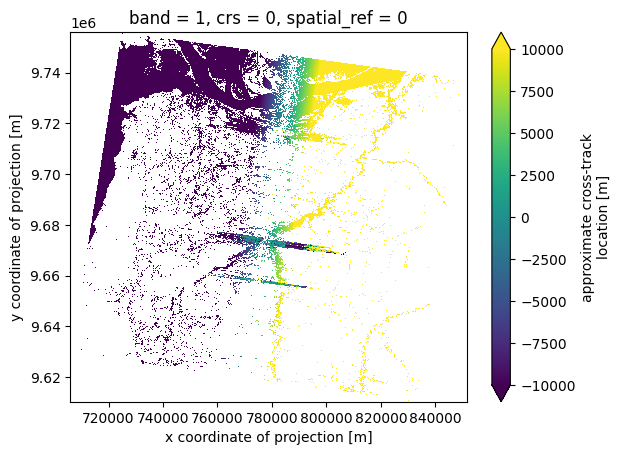

In [ ]:
idx = 0
cross_track = xrio.open_rasterio(files[idx]).squeeze()["cross_track"]
cross_track = cross_track.where(cross_track != cross_track.attrs["_FillValue"])
cross_track.plot(vmin=-10000, vmax=10000)

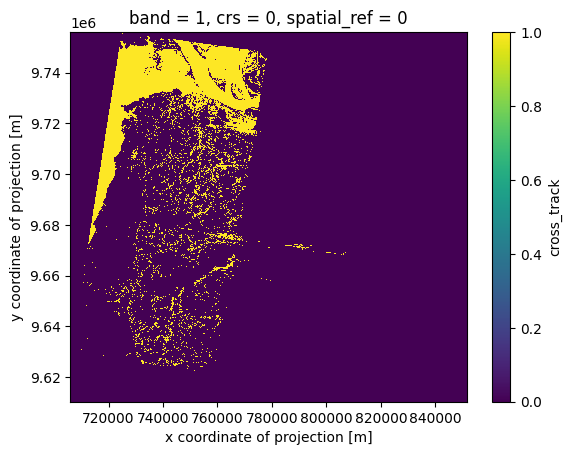

In [ ]:
(cross_track < -10000).plot()

In [ ]:
033_075F